# Executive_Dashboard

C:\Users\HUU THUC\AppData\Local\Temp\ipykernel_14468\1998583418.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df_month['month'] = pd.Categorical(df_month['month'], categories=months_order, ordered=True)


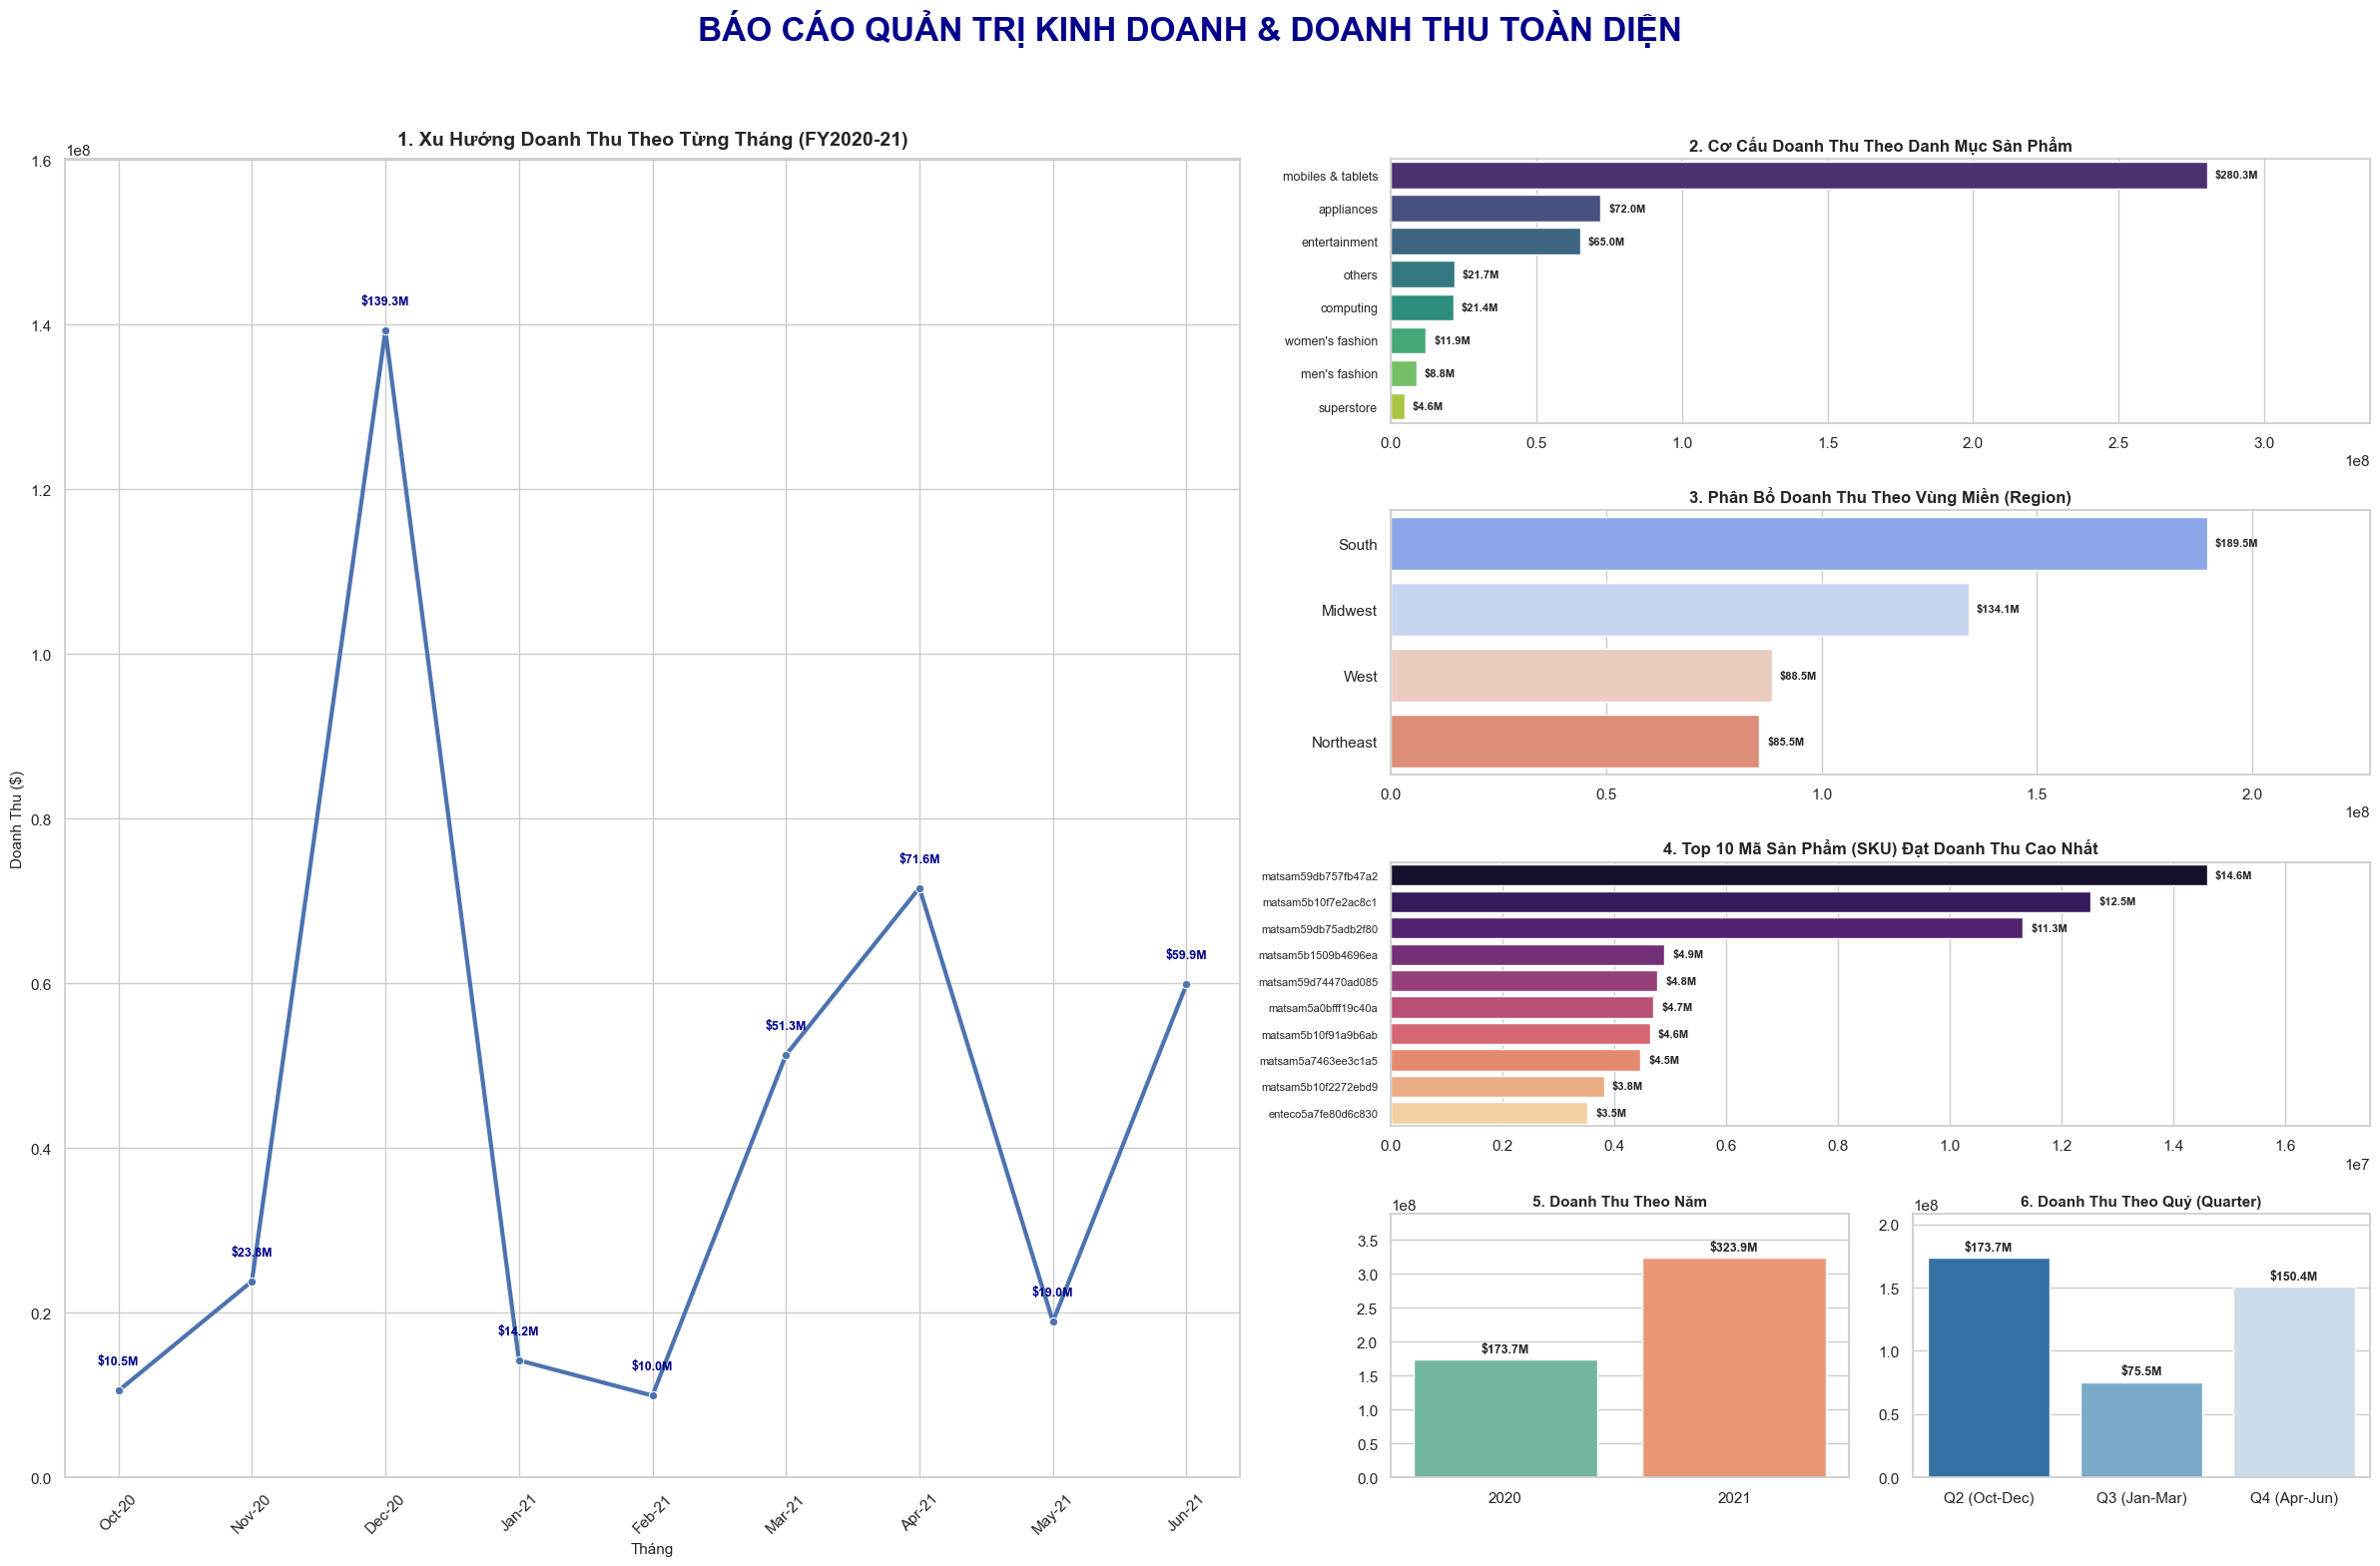

In [ ]:
# ############################################################################
# EXECUTIVE DASHBOARD
# Sinh viên thực hiện: Nguyễn Hữu Thức  
# Trường: FPT Polytechnic (Ho Chi Minh City)  
# ############################################################################

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CẤU HÌNH GIAO DIỆN CHUNG
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# Khởi tạo khung hình lớn chứa toàn bộ 6 biểu đồ
fig = plt.figure(figsize=(24, 16))
fig.suptitle('BÁO CÁO QUẢN TRỊ KINH DOANH & DOANH THU TOÀN DIỆN', 
             fontsize=24, fontweight='bold', color='darkblue', y=0.98)

# Thiết lập GridSpec bất đối xứng: Chia không gian làm 4 dòng x 2 cột
# Cột bên trái rộng hơn cột bên phải một chút để biểu đồ đường không bị ép
gs = fig.add_gridspec(4, 2, width_ratios=[1.2, 1])

# Định vị vị trí 6 ô biểu đồ theo sơ đồ lưới ảnh 2
ax1 = fig.add_subplot(gs[:, 0])   # Biểu đồ 1: Chiếm toàn bộ chiều cao cột 0 (bên trái)
ax2 = fig.add_subplot(gs[0, 1])   # Biểu đồ 2: Dòng 0, cột 1 (phía trên cùng bên phải)
ax3 = fig.add_subplot(gs[1, 1])   # Biểu đồ 3: Dòng 1, cột 1
ax4 = fig.add_subplot(gs[2, 1])   # Biểu đồ 4: Dòng 2, cột 1
# Tạo lưới phụ cho dòng cuối cùng bên phải để chia làm 2 ô nhỏ song song (Biểu đồ 5 và 6)
gs_bottom_right = gs[3, 1].subgridspec(1, 2)
ax5 = fig.add_subplot(gs_bottom_right[0, 0]) # Biểu đồ 5: Dòng 3, cột 1 - ô trái
ax6 = fig.add_subplot(gs_bottom_right[0, 1]) # Biểu đồ 6: Dòng 3, cột 1 - ô phải


# 2. ĐỌC VÀ CHUẨN BỊ DỮ LIỆU
path = "E:/Dự Án Tốt Nghiệp/PRO2291_duantotnghiep1/data/aggregates/"
df_category = pd.read_csv(path + "sales_by_category.csv")
df_month = pd.read_csv(path + "sales_by_month.csv")
df_region = pd.read_csv(path + "sales_by_region.csv")
df_year = pd.read_csv(path + "sales_by_year.csv")
df_top10 = pd.read_csv(path + "top_10_products.csv")

def clean_revenue(df):
    if 'revenue' in df.columns and df['revenue'].dtype == 'object':
        df['revenue'] = df['revenue'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
        df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
    return df

df_category = clean_revenue(df_category)
df_month = clean_revenue(df_month)
df_region = clean_revenue(df_region)
df_year = clean_revenue(df_year)
df_top10 = clean_revenue(df_top10)

# Sắp xếp lại thứ tự tháng cho Biểu đồ 1
months_order = ['Jul-20', 'Aug-20', 'Sep-20', 'Oct-20', 'Nov-20', 'Dec-20', 
                'Jan-21', 'Feb-21', 'Mar-21', 'Apr-21', 'May-21', 'Jun-21']
df_month['month'] = pd.Categorical(df_month['month'], categories=months_order, ordered=True)
df_month = df_month.sort_values('month')

# TỰ ĐỘNG TÍNH TOÁN DỮ LIỆU QUÝ TỪ DF_MONTH ĐỂ TRÁNH LỖI MERGE CORRUPT
# Tạo từ điển ánh xạ tháng sang quý theo năm tài chính của dự án
quarter_mapping = {
    'Jul-20': 'Q1 (Jul-Sep)', 'Aug-20': 'Q1 (Jul-Sep)', 'Sep-20': 'Q1 (Jul-Sep)',
    'Oct-20': 'Q2 (Oct-Dec)', 'Nov-20': 'Q2 (Oct-Dec)', 'Dec-20': 'Q2 (Oct-Dec)',
    'Jan-21': 'Q3 (Jan-Mar)', 'Feb-21': 'Q3 (Jan-Mar)', 'Mar-21': 'Q3 (Jan-Mar)',
    'Apr-21': 'Q4 (Apr-Jun)', 'May-21': 'Q4 (Apr-Jun)', 'Jun-21': 'Q4 (Apr-Jun)'
}

df_month_temp = df_month.copy()
df_month_temp['month_str'] = df_month_temp['month'].astype(str).str.strip()

# Thực hiện ánh xạ sang Quý
df_month_temp['quarter'] = df_month_temp['month_str'].map(quarter_mapping)

# Gom nhóm tính tổng doanh thu theo Quý
df_quarter = df_month_temp.groupby('quarter', as_index=False)['revenue'].sum()

# Đảm bảo thứ tự hiển thị chuẩn từ Q1 đến Q4 trên biểu đồ
df_quarter = df_quarter.sort_values(by='quarter')


# ============================================================================
# BIỂU ĐỒ 1: XU HƯỚNG DOANH THU THEO TỪNG THÁNG 
# ============================================================================
sns.lineplot(data=df_month, x='month', y='revenue', marker='o', color='b', linewidth=3, ax=ax1)
ax1.set_title('1. Xu Hướng Doanh Thu Theo Từng Tháng (FY2020-21)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Tháng', fontsize=11)
ax1.set_ylabel('Doanh Thu ($)', fontsize=11)
ax1.tick_params(axis='x', rotation=45)
offset = df_month['revenue'].max() * 0.02
for i in range(len(df_month)):
    row = df_month.iloc[i]
    if pd.notna(row['revenue']) and row['revenue'] > 0:
        val_in_m = row['revenue'] / 1000000
        ax1.text(x=row['month'], 
                 y=row['revenue'] + offset, 
                 s=f"${val_in_m:.1f}M", 
                 ha='center', va='bottom', fontsize=9, fontweight='bold', color='darkblue')

ax1.set_ylim(0, df_month['revenue'].max() * 1.15)


# ============================================================================
# BIỂU ĐỒ 2: CƠ CẤU DOANH THU THEO DANH MỤC SẢN PHẨM (CỘT NGANG)
# ============================================================================
df_category_sorted = df_category.sort_values(by='revenue', ascending=False).head(8) # Lấy top 8 để tránh chật ô lưới
sns.barplot(data=df_category_sorted, x='revenue', y='category', hue='category', palette='viridis', legend=False, ax=ax2)
ax2.set_title('2. Cơ Cấu Doanh Thu Theo Danh Mục Sản Phẩm', fontsize=12, fontweight='bold')
ax2.set_xlabel('', fontsize=9)
ax2.set_ylabel('', fontsize=9)
ax2.tick_params(axis='y', labelsize=9)

for patch in ax2.patches:
    width = patch.get_width()
    if width > 0:
        ax2.text(x=width + (df_category_sorted['revenue'].max() * 0.01), y=patch.get_y() + patch.get_height() / 2, 
                 s=f"${width/1000000:.1f}M", ha='left', va='center', fontsize=8, fontweight='bold')
ax2.set_xlim(0, df_category_sorted['revenue'].max() * 1.2)


# ============================================================================
# BIỂU ĐỒ 3: PHAN BỔ DOANH THU THEO VÙNG MIỀN (CỘT NGANG)
# ============================================================================
df_region_sorted = df_region.sort_values(by='revenue', ascending=False)
sns.barplot(data=df_region_sorted, x='revenue', y='region', hue='region', palette='coolwarm', legend=False, ax=ax3)
ax3.set_title('3. Phân Bổ Doanh Thu Theo Vùng Miền (Region)', fontsize=12, fontweight='bold')
ax3.set_xlabel('', fontsize=9)
ax3.set_ylabel('', fontsize=9)

for patch in ax3.patches:
    width = patch.get_width()
    if width > 0:
        ax3.text(x=width + (df_region_sorted['revenue'].max() * 0.01), y=patch.get_y() + patch.get_height() / 2, 
                 s=f"${width/1000000:.1f}M", ha='left', va='center', fontsize=8, fontweight='bold')
ax3.set_xlim(0, df_region_sorted['revenue'].max() * 1.2)


# ============================================================================
# BIỂU ĐỒ 4: TOP 10 MÃ SẢN PHẨM DOANH THU CAO NHẤT (CỘT NGANG)
# ============================================================================
df_top10_sorted = df_top10.sort_values(by='revenue', ascending=False)
sns.barplot(data=df_top10_sorted, x='revenue', y='sku', hue='sku', palette='magma', legend=False, ax=ax4)
ax4.set_title('4. Top 10 Mã Sản Phẩm (SKU) Đạt Doanh Thu Cao Nhất', fontsize=12, fontweight='bold')
ax4.set_xlabel('', fontsize=9)
ax4.set_ylabel('', fontsize=9)
ax4.tick_params(axis='y', labelsize=8)

for patch in ax4.patches:
    width = patch.get_width()
    if width > 0:
        ax4.text(x=width + (df_top10_sorted['revenue'].max() * 0.01), y=patch.get_y() + patch.get_height() / 2, 
                 s=f"${width/1000000:.1f}M", ha='left', va='center', fontsize=8, fontweight='bold')
ax4.set_xlim(0, df_top10_sorted['revenue'].max() * 1.2)


# ============================================================================
# BIỂU ĐỒ 5 (Ô DƯỚI - TRÁI): SO SÁNH DOANH THU NĂM 2020 VS 2021 (CỘT ĐỨNG)
# ============================================================================
df_year['year'] = df_year['year'].astype(str)
sns.barplot(data=df_year, x='year', y='revenue', hue='year', palette='Set2', legend=False, ax=ax5)
ax5.set_title('5. Doanh Thu Theo Năm', fontsize=11, fontweight='bold')
ax5.set_xlabel('', fontsize=9)
ax5.set_ylabel('', fontsize=9)

for patch in ax5.patches:
    height = patch.get_height()
    if height > 0:
        ax5.text(x=patch.get_x() + patch.get_width() / 2, y=height + (df_year['revenue'].max() * 0.02), 
                 s=f"${height/1000000:.1f}M", ha='center', va='bottom', fontsize=9, fontweight='bold')
ax5.set_ylim(0, df_year['revenue'].max() * 1.2)


# ============================================================================
# BIỂU ĐỒ 6 (Ô DƯỚI - PHẢI): DOANH THU THEO QUÝ - QUARTER (CỘT ĐỨNG)
# ============================================================================
sns.barplot(data=df_quarter, x='quarter', y='revenue', hue='quarter', palette='Blues_r', legend=False, ax=ax6)
ax6.set_title('6. Doanh Thu Theo Quý (Quarter)', fontsize=11, fontweight='bold')
ax6.set_xlabel('', fontsize=9)
ax6.set_ylabel('', fontsize=9)

for patch in ax6.patches:
    height = patch.get_height()
    if height > 0:
        ax6.text(x=patch.get_x() + patch.get_width() / 2, y=height + (df_quarter['revenue'].max() * 0.02), 
                 s=f"${height/1000000:.1f}M", ha='center', va='bottom', fontsize=9, fontweight='bold')
ax6.set_ylim(0, df_quarter['revenue'].max() * 1.2)


# 3. CĂN CHỈNH TOÀN DIỆN VÀ XUẤT FILE 
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('executive_6_in_1_dashboard.png', dpi=300)
plt.show()

# Total Revenue

In [1]:
import pandas as pd

df = pd.read_csv(
    r"D:\PRO2291_DuAnTopNghiep\PRO2291_duantotnghiep1\data\cleaned/sales_cleaned.csv",
    low_memory=False
)


In [2]:
total_revenue = df["total"].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $233,649,585.64


# Total Orders

In [3]:
total_orders = df["order_id"].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 201,715


# Total Customers

In [4]:
total_customers = df["cust_id"].nunique()

print(f"Total Customers: {total_customers:,}")

Total Customers: 64,248


# Average Order Value

In [5]:
aov = total_revenue / total_orders

print(f"AOV: ${aov:,.2f}")

AOV: $1,158.32
